# Why Binary Classification?

An image is not restricted to have one labelled finding. Meaning an image may be labelled as “Emphysema/Infiltration/Pleural_Thickening/Pneumothorax” while another might just be labelled with “Empyserma”. This is inherently noisy and can lead to imbalance problems around more edge case diseases. Given these issues, for this project we decided to simplify the problem into a Binary classification.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [7]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "nih_chest_xray" / "Data_Entry_2017.csv"
PROCESSED_LABELS_PATH = PROJECT_ROOT / "data" / "processed" / "binary_labels.csv"

raw_df = pd.read_csv(RAW_DATA_PATH)
processed_df = pd.read_csv(PROCESSED_LABELS_PATH)

raw_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [8]:
processed_df.head()

,image_id,image_path,label,target
0,00000001_000.png,data/raw/nih_chest_xray/images_001/images/0000...,abnormality,1
1,00000001_001.png,data/raw/nih_chest_xray/images_001/images/0000...,abnormality,1
2,00000001_002.png,data/raw/nih_chest_xray/images_001/images/0000...,abnormality,1
3,00000002_000.png,data/raw/nih_chest_xray/images_001/images/0000...,no_abnormality,0
4,00000003_000.png,data/raw/nih_chest_xray/images_001/images/0000...,abnormality,1


We added the full image path to the processed CSV so training/evaluation code can load each image directly from the label file without having to search through all images_001/images, images_002/images, etc. every time.

In [ ]:
raw_label_counts = (
    raw_df["Finding Labels"]                       
    .str.split(r"\|")                            # Some have multible abnormalities like this "Cardiomegaly|Effusion" 
    .explode()                                   # With this code we change it to this → ["Cardiomegaly", "Effusion"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="raw_count")
)

processed_label_counts = (
    processed_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="processed_count")
)

label_counts = (
    raw_label_counts
    .merge(processed_label_counts, on="label", how="outer")
    .fillna(0)
)

label_counts[["raw_count", "processed_count"]] = label_counts[
    ["raw_count", "processed_count"]
].astype(int)

label_counts = label_counts.sort_values(
    ["raw_count", "processed_count"],
    ascending=False,
)

display(label_counts)

,label,raw_count,processed_count
10,No Finding,60361,0
8,Infiltration,19894,0
4,Effusion,13317,0
0,Atelectasis,11559,0
11,Nodule,6331,0
9,Mass,5782,0
14,Pneumothorax,5302,0
2,Consolidation,4667,0
12,Pleural_Thickening,3385,0
1,Cardiomegaly,2776,0


We can see that the pipelinetransformation into binary classification data worked properly since "No Finding" and "no_abnormality" have the same count.

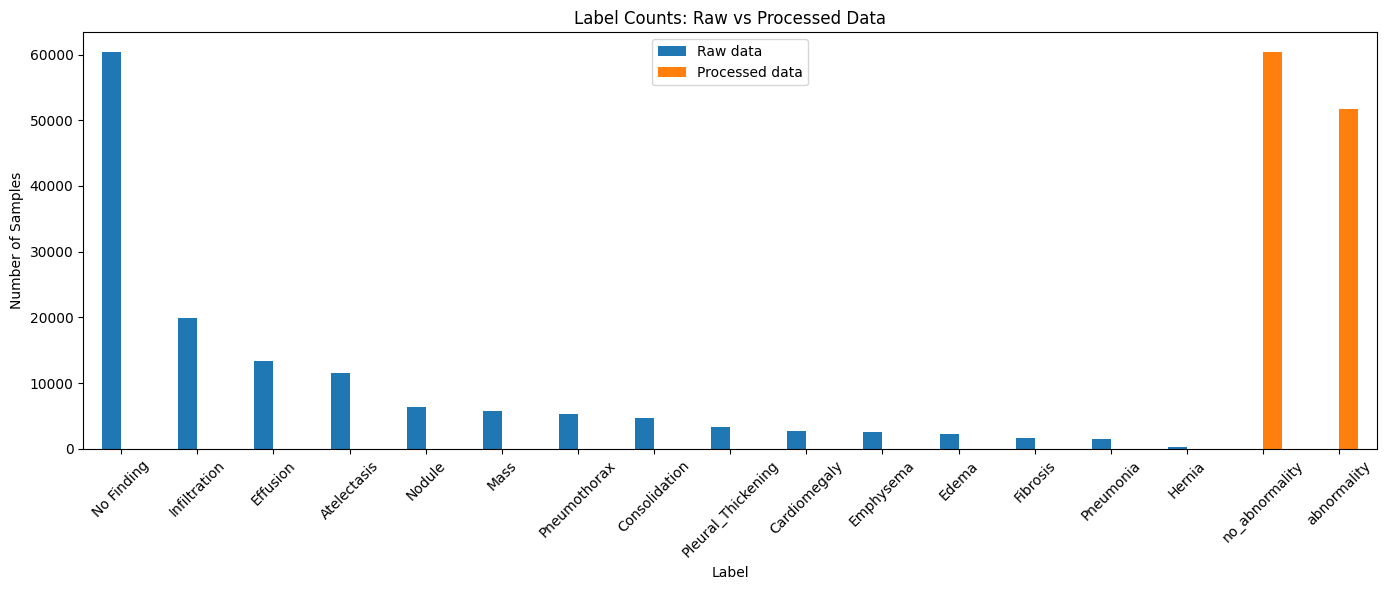

In [14]:
ax = label_counts.plot(
    x="label",
    y=["raw_count", "processed_count"],
    kind="bar",
    figsize=(14, 6),
)

ax.set_title("Label Counts: Raw vs Processed Data")
ax.set_xlabel("Label")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
ax.legend(["Raw data", "Processed data"])

plt.tight_layout()
plt.show()